# 03 · Feature Engineering

입력: `data/processed/corn_panel.parquet` (70,721행 / 2,644 카운티 / 1981–2015)
산출: `data/processed/features_stratA.parquet`, `features_stratB.parquet`, `feature_columns.json`
그림: `outputs/figures/`

### EDA(02)에서 확정된 제약 — 이 노트북이 반드시 반영해야 함
1. **총합 184 제약**: gdd 121개 합 = 항상 184일 → 전부 쓰면 완전 종속(더미변수 함정).
   → 요약 지표로 압축(전략 A)하거나 기준 구간 하나를 drop(전략 B).
2. **공선성**: 인접 온도구간 상관 0.94 → 정규화(Ridge/Lasso) 또는 구간 묶기.
3. **`slope` 결측 2,061개**: NC 52% 등 지역 통째 결측(MNAR) → 행을 버리지 않는다.

### 이 노트북에서 추가로 발견해 반영한 제약
4. **`sand + silt + clay = 100`** (결측 4행을 뺀 모든 행에서 정확히). soil 안에도 또 하나의 더미변수 함정이 있다.
   → 모델 피처에서 `silt`를 뺀다 (100 − sand − clay 로 완전 복원 가능).

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance

PROC = Path('..') / 'data' / 'processed'
FIG = Path('..') / 'outputs' / 'figures'
FIG.mkdir(parents=True, exist_ok=True)

SURFACE, INK, SECOND, MUTED = '#fcfcfb', '#0b0b0b', '#52514e', '#898781'
GRID, AXIS = '#e1e0d9', '#c3c2b7'
BLUE, AQUA, RED, GREEN = '#2a78d6', '#1baf7a', '#e34948', '#008300'

mpl.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150,
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': AXIS, 'axes.labelcolor': SECOND, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Malgun Gothic', 'Segoe UI', 'DejaVu Sans'],
    'axes.unicode_minus': False,
    'axes.titlesize': 12.5, 'axes.titleweight': 'semibold',
    'axes.labelsize': 10.5, 'lines.linewidth': 2,
})

def save(fig, name):
    p = FIG / name
    fig.savefig(p, bbox_inches='tight')
    print('saved:', p)

df = pd.read_parquet(PROC / 'corn_panel.parquet')
print('panel:', df.shape)

GDD = [c for c in df.columns if c.startswith('gdd')]
def temp_of(c):
    if c == 'gdd0':
        return 0
    return int(c[4:]) if c.startswith('gddp') else -int(c[4:])

SOIL_ALL = ['whc', 'sand', 'silt', 'clay', 'om', 'kwfactor', 'kffactor', 'spH', 'slope', 'tfactor']
DAYS = 184.0   # Mar-Aug 일수 = gdd 행별 총합

panel: (70721, 136)


## 1. 결측 처리

| 대상 | 결측 수 | 처리 |
|---|---|---|
| `gddm4` | 1 | **184 − 나머지 120개 합**으로 복원 (총합 제약 이용) |
| soil 8개 (`whc`,`sand`,`clay`,`om`,`kwfactor`,`kffactor`,`spH`,`tfactor`) | 각 4 | 전체 중앙값 |
| `silt` | 4 | **100 − sand − clay** 로 복원 (텍스처 제약 보존) |
| `slope` | 2,061 | **버전 A**: 컬럼 제외 · **버전 B**: 주(state) 중앙값 + `slope_missing` 지시자 |

`gddm4`는 중앙값(0.471)으로 채우는 것보다 총합 제약으로 복원하는 편이 정확하다 — 아래에서 확인.

In [2]:
df = df.copy()

# --- gddm4: 총합 184 제약으로 복원 ---
na_g = df['gddm4'].isna()
others = [c for c in GDD if c != 'gddm4']
recon = DAYS - df.loc[na_g, others].sum(axis=1)
r = df.loc[na_g].iloc[0]
print('gddm4 결측: stco=%d year=%d' % (r.stco, r.year))
print('  복원값 = 184 - 나머지합 = %.4f   (이웃 gddm5=%.3f, gddm3=%.3f)'
      % (recon.iloc[0], r.gddm5, r.gddm3))
print('  참고: 전체 중앙값 %.3f 로 채웠다면 이웃과 어긋남' % df['gddm4'].median())
df.loc[na_g, 'gddm4'] = recon

# --- soil 소수 결측: 텍스처 제약(sand+silt+clay=100)을 보존하며 대체 ---
tex_raw = df[['sand', 'silt', 'clay']].dropna().sum(axis=1)
print('\n[대체 전] sand+silt+clay (결측 4행 제외, %d행): min %.4f  max %.4f  -> 정확히 100'
      % (len(tex_raw), tex_raw.min(), tex_raw.max()))

# sand/clay 는 중앙값, silt 는 제약식으로 복원 -> 4행에서도 합이 정확히 100 유지
SOIL_MEDIAN = ['whc', 'sand', 'clay', 'om', 'kwfactor', 'kffactor', 'spH', 'tfactor']
n_med = int(df[SOIL_MEDIAN].isna().sum().sum())
df[SOIL_MEDIAN] = df[SOIL_MEDIAN].fillna(df[SOIL_MEDIAN].median())
n_silt = int(df['silt'].isna().sum())
df['silt'] = df['silt'].fillna(100.0 - df['sand'] - df['clay'])
n_minor = n_med + n_silt
print('soil 대체: 중앙값 %d셀(8개 컬럼) + silt %d셀은 100-sand-clay 로 복원 (합계 %d셀)'
      % (n_med, n_silt, n_minor))

# --- slope : 주(state) 중앙값 + 지시자 ---
df['state'] = df['stco'] // 1000
df['slope_missing'] = df['slope'].isna().astype('int8')
state_med = df.groupby('state')['slope'].transform('median')
n_slope = int(df['slope'].isna().sum())
df['slope'] = df['slope'].fillna(state_med)
n_left = int(df['slope'].isna().sum())
df['slope'] = df['slope'].fillna(df['slope'].median())   # 방어적 fallback (실제로는 불필요)
print('slope 결측 %d행 -> 주 중앙값 대체 (주 전체가 결측인 州 없음, fallback 사용 %d행)'
      % (n_slope, n_left))
print('slope_missing = 1 인 행: %d (%.2f%%)' % (df.slope_missing.sum(), 100 * df.slope_missing.mean()))

assert df[GDD + SOIL_ALL + ['ppt']].isna().sum().sum() == 0
print('\n남은 결측: 0  (확인 완료)')

gddm4 결측: stco=36117 year=2013
  복원값 = 184 - 나머지합 = 2.3104   (이웃 gddm5=1.331, gddm3=2.046)
  참고: 전체 중앙값 0.471 로 채웠다면 이웃과 어긋남

[대체 전] sand+silt+clay (결측 4행 제외, 70717행): min 100.0000  max 100.0000  -> 정확히 100
soil 대체: 중앙값 32셀(8개 컬럼) + silt 4셀은 100-sand-clay 로 복원 (합계 36셀)
slope 결측 2061행 -> 주 중앙값 대체 (주 전체가 결측인 州 없음, fallback 사용 0행)
slope_missing = 1 인 행: 2061 (2.91%)



남은 결측: 0  (확인 완료)


### 더미변수 함정 두 개 확인

184 제약은 EDA에서 확인했고, soil 안에도 하나가 더 있다.

In [3]:
row_sum = df[GDD].sum(axis=1)
print('gdd 121개 행별 합 : mean %.4f  std %.5f  -> 사실상 상수(184)' % (row_sum.mean(), row_sum.std()))

tex = df[['sand', 'silt', 'clay']].sum(axis=1)
print('sand+silt+clay    : min %.4f  max %.4f  std %.6f  -> 대체 후에도 정확히 100 유지'
      % (tex.min(), tex.max(), tex.std()))
assert np.allclose(tex, 100.0), '텍스처 제약이 깨졌다'
print('\n=> 모델 피처에서 silt 제외 (100 - sand - clay 로 복원 가능)')
print('   kwfactor vs kffactor 상관 %.3f (강하지만 정확한 종속은 아님 -> 둘 다 유지)'
      % df.kwfactor.corr(df.kffactor))

SOIL_FEAT = ['whc', 'sand', 'clay', 'om', 'kwfactor', 'kffactor', 'spH', 'tfactor']  # silt 제외
print('\nSOIL_FEAT (%d개): %s' % (len(SOIL_FEAT), SOIL_FEAT))

gdd 121개 행별 합 : mean 183.9996  std 0.01207  -> 사실상 상수(184)
sand+silt+clay    : min 100.0000  max 100.0000  std 0.000000  -> 대체 후에도 정확히 100 유지

=> 모델 피처에서 silt 제외 (100 - sand - clay 로 복원 가능)
   kwfactor vs kffactor 상관 0.884 (강하지만 정확한 종속은 아님 -> 둘 다 유지)

SOIL_FEAT (8개): ['whc', 'sand', 'clay', 'om', 'kwfactor', 'kffactor', 'spH', 'tfactor']


## 2. 전략 A — 도메인 압축 (Schlenker–Roberts 스타일)

- `GDD_below_T` = 1℃ ~ T℃ 구간 일수 합 (유익 노출)
- `GDD_above_T` = T℃ 초과 구간 일수 합 (유해 고온 노출)
- **0℃ 이하 냉량 구간이 자동으로 reference** 가 되어 184 제약이 해소된다.
- `ppt`, `ppt_sq`, soil 8개(`silt` 제외)

임계 T = 28/29/30/31 네 버전을 모두 만들어 민감도를 본다. 타깃은 **연도 평균을 뺀 `corn_dm`**
(02에서 확인한 +1.77 bu/ac/년 기술 추세를 제거해야 기후 효과가 드러남).

In [4]:
df['corn_dm'] = df['corn'] - df.groupby('year')['corn'].transform('mean')
df['ppt_sq'] = df['ppt'] ** 2

THRESHOLDS = [28, 29, 30, 31]
CANON_T = 29          # 프로젝트 전제 임계값 (민감도는 아래에서 별도 확인)

for t in THRESHOLDS:
    bel = [c for c in GDD if c.startswith('gddp') and 1 <= temp_of(c) <= t]
    abv = [c for c in GDD if c.startswith('gddp') and temp_of(c) > t]
    df['GDD_below_%d' % t] = df[bel].sum(axis=1)
    df['GDD_above_%d' % t] = df[abv].sum(axis=1)

cold = [c for c in GDD if temp_of(c) <= 0]
df['GDD_cold'] = df[cold].sum(axis=1)   # reference (모델에는 넣지 않음)

chk = df['GDD_below_29'] + df['GDD_above_29'] + df['GDD_cold']
print('below29 + above29 + cold = %.3f (std %.4f)  -> 184 복원 확인' % (chk.mean(), chk.std()))
print()
print(df[['GDD_below_29', 'GDD_above_29', 'GDD_cold', 'ppt']].describe().round(2).to_string())

below29 + above29 + cold = 184.000 (std 0.0121)  -> 184 복원 확인

       GDD_below_29  GDD_above_29  GDD_cold       ppt
count      70721.00      70721.00  70721.00  70721.00
mean         152.61         23.59      7.79    635.34
std           13.15         16.80      7.57    209.22
min           74.93          0.00      0.00      0.94
25%          144.99          9.80      1.49    513.24
50%          154.59         20.57      5.55    637.07
75%          162.02         34.37     12.20    766.42
max          183.86        109.07     56.26   1601.69


### 2-1. 임계점 민감도 — 임계점이 데이터에서 드러나는가?

각 임계 T마다 두 가지 회귀의 R²를 본다.
- **simple**: `corn_dm ~ GDD_below_T + GDD_above_T`
- **full**: 위 + `ppt`, `ppt_sq`, soil 8개

T를 20~40℃까지 훑어서 R²가 최대가 되는 지점을 찾는다.

In [5]:
y = df['corn_dm'].to_numpy()
ctrl = df[['ppt', 'ppt_sq'] + SOIL_FEAT].to_numpy()

def ols_r2(X, y):
    X1 = np.column_stack([np.ones(len(X)), X])
    b, *_ = np.linalg.lstsq(X1, y, rcond=None)
    resid = y - X1 @ b
    return 1 - (resid ** 2).sum() / ((y - y.mean()) ** 2).sum(), b

rows = []
for t in range(20, 41):
    bel = df[[c for c in GDD if c.startswith('gddp') and 1 <= temp_of(c) <= t]].sum(axis=1).to_numpy()
    abv = df[[c for c in GDD if c.startswith('gddp') and temp_of(c) > t]].sum(axis=1).to_numpy()
    r2s, bs = ols_r2(np.column_stack([bel, abv]), y)
    r2f, _ = ols_r2(np.column_stack([bel, abv, ctrl]), y)
    rows.append((t, r2s, r2f, bs[1], bs[2], bs[2] - bs[1]))

sens = pd.DataFrame(rows, columns=['thr', 'R2_simple', 'R2_full', 'b_below', 'b_above', 'subst'])
best_s = int(sens.loc[sens.R2_simple.idxmax(), 'thr'])
best_f = int(sens.loc[sens.R2_full.idxmax(), 'thr'])
print('R2_simple 최대: T=%d (%.4f)' % (best_s, sens.R2_simple.max()))
print('R2_full   최대: T=%d (%.4f)' % (best_f, sens.R2_full.max()))
print()
print('요청된 28/29/30/31:')
print(sens[sens['thr'].isin(THRESHOLDS)].round(4).to_string(index=False))
print()
zc = sens[sens.b_above < 0]['thr'].min()
print('b_above 가 음수로 바뀌는 첫 임계: T=%d  (그 아래 T=%d 에서는 %+.4f)'
      % (zc, zc - 1, sens.loc[sens.thr == zc - 1, 'b_above'].iloc[0]))

R2_simple 최대: T=28 (0.0641)
R2_full   최대: T=31 (0.2465)

요청된 28/29/30/31:
 thr  R2_simple  R2_full  b_below  b_above   subst
  28     0.0641   0.2377   0.4074  -0.1371 -0.5445
  29     0.0632   0.2427   0.3189  -0.2648 -0.5837
  30     0.0597   0.2458   0.2042  -0.4213 -0.6255
  31     0.0537   0.2465   0.0701  -0.6004 -0.6704

b_above 가 음수로 바뀌는 첫 임계: T=27  (그 아래 T=26 에서는 +0.0305)


saved: ..\outputs\figures\fig10_threshold_sensitivity.png


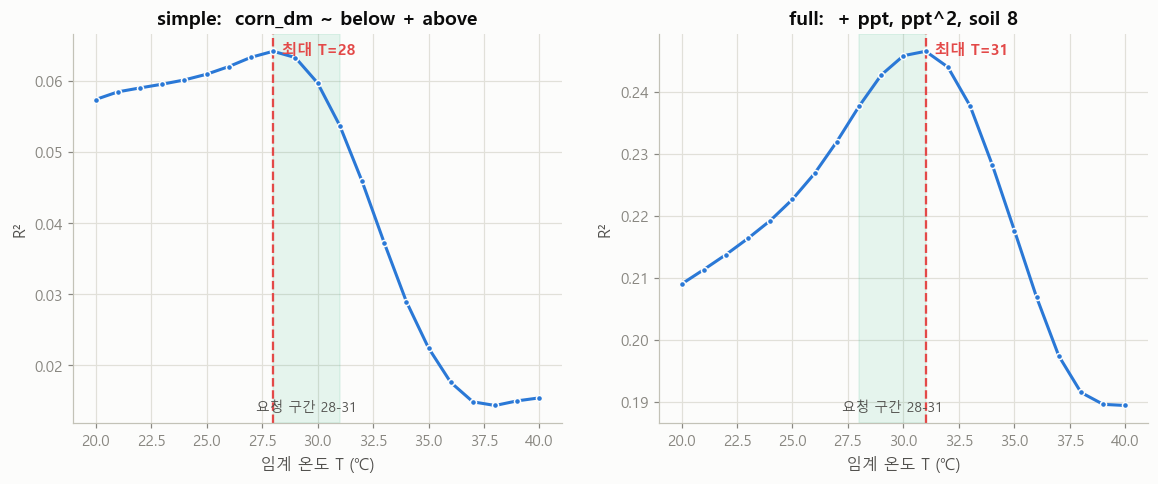

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.6))
for ax, col, ttl, best in [
        (axes[0], 'R2_simple', 'simple:  corn_dm ~ below + above', best_s),
        (axes[1], 'R2_full', 'full:  + ppt, ppt^2, soil 8', best_f)]:
    ax.set_axisbelow(True)
    ax.axvspan(28, 31, color=AQUA, alpha=0.10, zorder=1)
    ax.plot(sens['thr'], sens[col], color=BLUE, marker='o', markersize=4,
            markeredgecolor=SURFACE, markeredgewidth=1.0, zorder=3)
    ax.axvline(best, color=RED, linestyle='--', linewidth=1.5, zorder=2)
    ax.annotate('최대 T=%d' % best, xy=(best, sens[col].max()), xytext=(6, -2),
                textcoords='offset points', color=RED, fontsize=10, fontweight='semibold')
    ax.annotate('요청 구간 28-31', xy=(29.5, ax.get_ylim()[0]), xytext=(0, 8),
                textcoords='offset points', ha='center', color=SECOND, fontsize=9)
    ax.set_title(ttl)
    ax.set_xlabel('임계 온도 T (℃)'); ax.set_ylabel('R²')
save(fig, 'fig10_threshold_sensitivity.png'); plt.show()

**해석 — 임계점은 넓고 얕은 고원(plateau)이지 날카로운 꺾임점이 아니다.**

- 통제변수 없이는 **T=28에서 R² 최대(0.0641)**, soil·ppt를 넣으면 **T=31에서 최대(0.2465)** 로 이동한다.
- 요청된 28/29/30/31 사이의 R² 차이는 **1%p 미만**(full 기준 0.2377 → 0.2465, 차이 0.0089)으로 매우 얕다.
  즉 **데이터가 특정 임계를 날카롭게 지목하지는 않는다**. 29℃는 이 고원 안에 충분히 들어온다.
- 다만 `b_above`(고온 노출의 계수)가 **양수에서 음수로 바뀌는 지점은 T=27** 근처로 뚜렷하다.
  "몇 도부터 추가 노출이 해로워지는가"라는 질문에는 **26~28℃** 라는 답이 나온다.
- 이후 분석은 프로젝트 전제인 **T=29(CANON_T)** 를 기준으로 하되, 네 버전을 모두 저장해
  04에서 성능 비교가 가능하게 한다.

### 2-2. ⚠️ 계수 부호를 그대로 읽으면 안 되는 이유

`GDD_below`/`GDD_above`의 개별 계수는 **"≤0℃ 냉량일 1일을 그 구간으로 바꿀 때"** 의 효과다
(냉량 구간이 reference이므로). 통제변수를 추가하면 **둘 다 양수**가 되기도 한다 — 얼어붙은 하루보다는
더운 하루가 낫기 때문이지, "고온이 이롭다"는 뜻이 결코 아니다.

해석 가능한 불변량은 **대체효과 `b_above − b_below`** (온화한 1일을 고온 1일로 바꿀 때)다.

In [7]:
SOIL8 = SOIL_FEAT
bel29 = df['GDD_below_29'].to_numpy(); abv29 = df['GDD_above_29'].to_numpy()
specs = [
    ('below+above 만',      np.column_stack([bel29, abv29])),
    ('+ ppt',               np.column_stack([bel29, abv29, df.ppt])),
    ('+ ppt, ppt²',         np.column_stack([bel29, abv29, df.ppt, df.ppt_sq])),
    ('+ ppt, ppt², soil 8', np.column_stack([bel29, abv29, df.ppt, df.ppt_sq, df[SOIL8]])),
]
print('%-22s %8s %10s %10s %12s' % ('통제변수', 'R²', 'b_below', 'b_above', '대체효과'))
print('-' * 66)
for name, X in specs:
    r2, b = ols_r2(X, y)
    print('%-22s %8.4f %+10.4f %+10.4f %+12.4f' % (name, r2, b[1], b[2], b[2] - b[1]))
print()
print('=> 개별 부호는 통제변수에 따라 뒤집히지만, 대체효과는 일관되게 음수이고 오히려 강해진다.')

통제변수                         R²    b_below    b_above         대체효과
------------------------------------------------------------------
below+above 만            0.0632    +0.3189    -0.2648      -0.5837
+ ppt                    0.0766    +0.5374    -0.1278      -0.6653
+ ppt, ppt²              0.0834    +0.5094    -0.1702      -0.6796
+ ppt, ppt², soil 8      0.2427    +1.4030    +0.6914      -0.7115

=> 개별 부호는 통제변수에 따라 뒤집히지만, 대체효과는 일관되게 음수이고 오히려 강해진다.


**결과 —** soil을 넣는 순간 `b_below`(+1.403), `b_above`(+0.691) **둘 다 양수**가 된다.
하지만 **대체효과는 −0.584 → −0.665 → −0.680 → −0.712 로 일관되게 음수이며 오히려 강해진다.**

> 아래 Lasso 계수표에서 `GDD_above_29`가 **양수**로 나오는 것도 같은 이유다.
> 이걸 "고온이 수확량을 올린다"로 읽으면 완전히 틀린다. 04에서 계수를 보고할 때 반드시
> reference 구간(≤0℃)을 명시하고, 대체효과 형태로 환산해서 보고해야 한다.

## 3. 전략 B — 원자료 온도 구간 + 정규화용

- 노출이 실제로 있는 구간(합 ≠ 0)만 사용 → 87개
- 184 제약 해소를 위해 **기준 구간 하나를 명시적으로 drop**.
  기준은 **평균 노출이 가장 큰 구간**을 고른다. 질량이 큰 구간을 빼야 남은 합의 분산이 커져
  조건수가 개선되고, "24℃에서의 하루 대신"이라는 자연스러운 해석이 생긴다.
- `ppt`, `ppt_sq`, soil 8개 동일. 표준화는 **파이프라인 안에서** 수행한다(아래 이유).

In [8]:
nz = [c for c in GDD if df[c].sum() > 0]
mean_exp = df[nz].mean().sort_values(ascending=False)
REF_BIN = mean_exp.index[0]
print('노출 있는 구간: %d개 (%d℃ ~ %d℃)' % (len(nz), temp_of(nz[0]), temp_of(nz[-1])))
print('평균 노출 상위 3:'); print(mean_exp.head(3).round(3).to_string())
print('\n=> 기준(reference) 구간으로 %s (%d℃, 평균 %.2f일) 를 drop'
      % (REF_BIN, temp_of(REF_BIN), mean_exp.iloc[0]))

GDD_B = [c for c in nz if c != REF_BIN]
print('전략 B 온도구간 피처: %d개' % len(GDD_B))

FEAT_B = GDD_B + ['ppt', 'ppt_sq'] + SOIL_FEAT
print('전략 B 총 피처(슬로프 제외): %d개' % len(FEAT_B))

노출 있는 구간: 87개 (-36℃ ~ 50℃)
평균 노출 상위 3:
gddp24    8.504
gddp23    8.444
gddp25    8.415

=> 기준(reference) 구간으로 gddp24 (24℃, 평균 8.50일) 를 drop
전략 B 온도구간 피처: 86개
전략 B 총 피처(슬로프 제외): 96개


### 표준화는 왜 파일로 저장하지 않는가

전체 데이터로 `StandardScaler`를 fit해서 저장하면 **테스트 셋의 평균/분산이 학습에 새어든다(leakage)**.
올바른 방법은 스케일러를 **CV 파이프라인 안에 넣어 학습 fold에서만 fit** 하는 것이다.
따라서 parquet에는 **원 스케일 피처**를 저장하고, 아래처럼 04에서 바로 쓸 수 있는 파이프라인을 준비해 둔다.

In [9]:
# 04에서 그대로 쓸 수 있는 형태 — 스케일러가 파이프라인 안에 있다
ridge_pipe = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 4, 25)))

# 카운티 그룹 분할(공간 누수 방지)로 빠른 sanity check
Xb = df[FEAT_B].to_numpy()
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_g, te_g = next(gss.split(Xb, y, groups=df['stco']))
ridge_pipe.fit(Xb[tr_g], y[tr_g])
print('전략 B + Ridge (county-grouped holdout) R² = %.4f' % ridge_pipe.score(Xb[te_g], y[te_g]))
print('선택된 alpha = %.3f' % ridge_pipe[-1].alpha_)
print('\n(참고용 sanity check일 뿐, 본격 평가는 04에서)')

전략 B + Ridge (county-grouped holdout) R² = 0.2440
선택된 alpha = 177.828

(참고용 sanity check일 뿐, 본격 평가는 04에서)


## 4. 피처 중요도 (전략 A 기준)

전략 B(온도구간 86개)는 공선성 0.94 때문에 개별 중요도가 불안정하므로 **중요도는 전략 A로 본다**.

- **Lasso** 계수 (학습 fold에서 fit한 StandardScaler 적용)
- **RandomForest / GradientBoosting** `feature_importances_` (불순도 기반)
- **Permutation importance** (홀드아웃) — 불순도 기반은 편향이 있어 이걸 주 기준으로 삼는다

분할은 두 가지로 본다: **무작위 분할**(같은 카운티가 학습/테스트에 모두 등장 → 낙관적)과
**카운티 그룹 분할**(공간 누수 차단).

In [10]:
FEAT_A_noslope = ['GDD_below_%d' % CANON_T, 'GDD_above_%d' % CANON_T, 'ppt', 'ppt_sq'] + SOIL_FEAT
FEAT_A_slope = FEAT_A_noslope + ['slope', 'slope_missing']
print('slope 버전 A: %d개 피처' % len(FEAT_A_noslope))
print('slope 버전 B: %d개 피처 (+slope, +slope_missing)' % len(FEAT_A_slope))

idx_tr, idx_te = train_test_split(np.arange(len(df)), test_size=0.2, random_state=42)

def fit_all(feats, split, tag):
    X = df[feats].to_numpy()
    a, b = split
    Xtr, Xte, ytr, yte = X[a], X[b], y[a], y[b]
    sc = StandardScaler().fit(Xtr)                       # 학습 fold에서만 fit
    las = LassoCV(cv=5, n_jobs=-1, random_state=0, max_iter=5000).fit(sc.transform(Xtr), ytr)
    rf = RandomForestRegressor(n_estimators=200, min_samples_leaf=5,
                               n_jobs=-1, random_state=0).fit(Xtr, ytr)
    gb = GradientBoostingRegressor(n_estimators=200, max_depth=3, subsample=0.7,
                                   random_state=0).fit(Xtr, ytr)
    perm = permutation_importance(rf, Xte, yte, n_repeats=5, n_jobs=-1, random_state=0)
    out = pd.DataFrame({'feature': feats,
                        'lasso_coef': las.coef_,
                        'rf_imp': rf.feature_importances_,
                        'gb_imp': gb.feature_importances_,
                        'perm_imp': perm.importances_mean}).sort_values('perm_imp', ascending=False)
    scores = {'lasso': las.score(sc.transform(Xte), yte),
              'rf': rf.score(Xte, yte), 'gb': gb.score(Xte, yte)}
    print('[%s]  holdout R²  lasso %.4f | rf %.4f | gb %.4f' % (tag, scores['lasso'], scores['rf'], scores['gb']))
    return out, scores

impA, scA = fit_all(FEAT_A_noslope, (idx_tr, idx_te), 'slope 버전 A · 무작위 분할')
print()
print(impA.round(4).to_string(index=False))

slope 버전 A: 12개 피처
slope 버전 B: 14개 피처 (+slope, +slope_missing)


[slope 버전 A · 무작위 분할]  holdout R²  lasso 0.2396 | rf 0.6537 | gb 0.5005

     feature  lasso_coef  rf_imp  gb_imp  perm_imp
         spH     10.8409  0.2093  0.2600    0.4562
GDD_below_29     18.3859  0.1218  0.1380    0.1891
GDD_above_29     11.4376  0.1018  0.1040    0.1477
         whc      2.8882  0.0960  0.0968    0.1432
          om      0.8506  0.0856  0.0795    0.1328
        clay    -13.0781  0.0754  0.0620    0.1208
     tfactor      3.2133  0.0667  0.0418    0.1001
    kwfactor     -0.6710  0.0562  0.0810    0.0865
        sand    -13.1299  0.0552  0.0255    0.0665
    kffactor     -3.4067  0.0396  0.0332    0.0606
      ppt_sq      2.7994  0.0463  0.0410    0.0302
         ppt     -2.0265  0.0461  0.0372    0.0284


saved: ..\outputs\figures\fig11_feature_importance.png


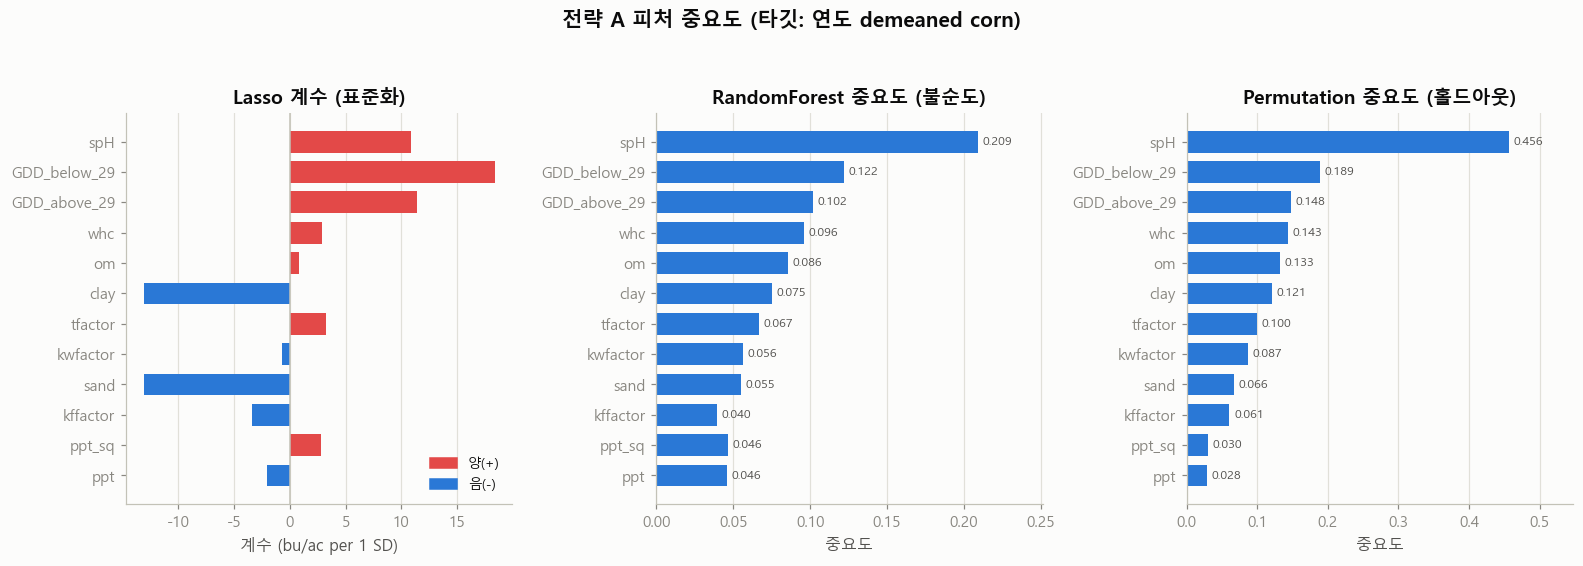

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 5.2))
order = impA.sort_values('perm_imp')

ax = axes[0]; ax.set_axisbelow(True); ax.grid(axis='y', visible=False)
lc = order.set_index('feature')['lasso_coef']
cols = [RED if v > 0 else BLUE for v in lc.values]
ax.barh(lc.index, lc.values, color=cols, height=0.72)
ax.axvline(0, color=AXIS, linewidth=1)
ax.set_title('Lasso 계수 (표준화)')
ax.set_xlabel('계수 (bu/ac per 1 SD)')
h = [plt.Rectangle((0, 0), 1, 1, color=RED), plt.Rectangle((0, 0), 1, 1, color=BLUE)]
ax.legend(h, ['양(+)', '음(-)'], frameon=False, fontsize=9, loc='lower right')

for ax, col, ttl in [(axes[1], 'rf_imp', 'RandomForest 중요도 (불순도)'),
                     (axes[2], 'perm_imp', 'Permutation 중요도 (홀드아웃)')]:
    ax.set_axisbelow(True); ax.grid(axis='y', visible=False)
    s = order.set_index('feature')[col]
    ax.barh(s.index, s.values, color=BLUE, height=0.72)
    for i, v in enumerate(s.values):
        ax.annotate('%.3f' % v, xy=(v, i), xytext=(3, 0), textcoords='offset points',
                    va='center', color=SECOND, fontsize=8)
    ax.set_xlim(0, s.max() * 1.20)
    ax.set_title(ttl); ax.set_xlabel('중요도')

fig.suptitle('전략 A 피처 중요도 (타깃: 연도 demeaned corn)', fontsize=13.5, fontweight='semibold')
fig.tight_layout(rect=[0, 0, 1, 0.94])
save(fig, 'fig11_feature_importance.png'); plt.show()

In [12]:
# 공간 누수 점검: 카운티 그룹 분할로 다시
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_c, te_c = next(gss2.split(df[FEAT_A_noslope].to_numpy(), y, groups=df['stco']))
impA_grp, scA_grp = fit_all(FEAT_A_noslope, (tr_c, te_c), 'slope 버전 A · 카운티 그룹 분할')
print()
print(impA_grp[['feature', 'perm_imp', 'rf_imp']].round(4).to_string(index=False))
print()
print('무작위 분할 RF R² %.4f  vs  카운티 그룹 분할 RF R² %.4f  (차이 %+.4f)'
      % (scA['rf'], scA_grp['rf'], scA_grp['rf'] - scA['rf']))
print('상위 3 피처 (무작위)     :', list(impA.feature[:3]))
print('상위 3 피처 (그룹 분할)  :', list(impA_grp.feature[:3]))

[slope 버전 A · 카운티 그룹 분할]  holdout R²  lasso 0.2051 | rf 0.4484 | gb 0.4169

     feature  perm_imp  rf_imp
         spH    0.3252  0.2152
GDD_below_29    0.1556  0.1147
GDD_above_29    0.1142  0.1051
        clay    0.0850  0.0733
          om    0.0808  0.0863
         whc    0.0704  0.1008
     tfactor    0.0496  0.0678
        sand    0.0376  0.0545
    kffactor    0.0369  0.0416
    kwfactor    0.0364  0.0471
      ppt_sq    0.0320  0.0466
         ppt    0.0304  0.0469

무작위 분할 RF R² 0.6537  vs  카운티 그룹 분할 RF R² 0.4484  (차이 -0.2053)
상위 3 피처 (무작위)     : ['spH', 'GDD_below_29', 'GDD_above_29']
상위 3 피처 (그룹 분할)  : ['spH', 'GDD_below_29', 'GDD_above_29']


**해석 — 순위는 안정적이지만 R²는 무작위 분할에서 크게 부풀려진다.**

- 무작위 분할 RF R² **0.654** → 카운티 그룹 분할 **0.448**. 같은 카운티가 학습/테스트에 함께
  등장하면 모델이 카운티 고정효과를 외워버린다. **04의 평가는 반드시 그룹/시계열 분할로.**
- 두 분할 모두 상위 3개는 **`spH` > `GDD_below_29` > `GDD_above_29`** 로 동일하다.
- **고온 노출(`GDD_above_29`)은 12개 피처 중 3위**로 확실히 상위다. 강수(`ppt`, `ppt_sq`)는
  최하위권 — 생육기 전체 강수 총량은 온도 노출보다 훨씬 약한 신호다.
- `spH`(토양 pH)가 1위인 것은 뜻밖이지만 그룹 분할에서도 유지된다. 다만 이는 **카운티 고유의
  정적 특성**이라 "옥수수가 잘 되는 지역"을 식별하는 대리변수 역할이 크다 — 인과적 처방으로
  읽으면 안 된다.
- Lasso에서 `GDD_above_29` 계수가 **양수**인 것은 2-2절에서 설명한 reference(≤0℃) 때문이다.
  절대 "고온이 이롭다"로 읽지 말 것.

## 5. slope 버전 A vs B — slope는 실제로 쓸모가 있는가?

In [13]:
impB, scB = fit_all(FEAT_A_slope, (idx_tr, idx_te), 'slope 버전 B · 무작위 분할')
print()
print(impB.round(4).to_string(index=False))

rank_slope = int(impB.reset_index(drop=True).index[impB.reset_index(drop=True).feature == 'slope'][0]) + 1
rank_miss = int(impB.reset_index(drop=True).index[impB.reset_index(drop=True).feature == 'slope_missing'][0]) + 1
print()
print('RF holdout R²   A(slope 없음) %.4f   B(slope 있음) %.4f   차이 %+.4f'
      % (scA['rf'], scB['rf'], scB['rf'] - scA['rf']))
print('B에서 slope 순위 %d/%d,  slope_missing 순위 %d/%d (perm 기준)'
      % (rank_slope, len(FEAT_A_slope), rank_miss, len(FEAT_A_slope)))
print('slope_missing perm 중요도 = %.5f (사실상 0)'
      % impB.loc[impB.feature == 'slope_missing', 'perm_imp'].iloc[0])

[slope 버전 B · 무작위 분할]  holdout R²  lasso 0.2397 | rf 0.6572 | gb 0.5044

      feature  lasso_coef  rf_imp  gb_imp  perm_imp
          spH     10.7028  0.2008  0.2572    0.4476
 GDD_below_29     18.4390  0.1207  0.1475    0.1872
          whc      3.0179  0.0905  0.0938    0.1412
 GDD_above_29     11.4645  0.0986  0.0882    0.1410
           om      0.9653  0.0734  0.0644    0.1066
         clay    -12.7976  0.0649  0.0588    0.0933
      tfactor      3.1732  0.0585  0.0356    0.0861
        slope      0.8064  0.0690  0.0450    0.0852
     kwfactor     -0.7713  0.0496  0.0837    0.0783
         sand    -12.7593  0.0499  0.0204    0.0570
     kffactor     -3.0828  0.0357  0.0314    0.0499
          ppt     -1.8237  0.0430  0.0295    0.0264
       ppt_sq      2.6452  0.0441  0.0440    0.0258
slope_missing     -0.4408  0.0012  0.0007    0.0010

RF holdout R²   A(slope 없음) 0.6537   B(slope 있음) 0.6572   차이 +0.0036
B에서 slope 순위 8/14,  slope_missing 순위 14/14 (perm 기준)
slope_missing perm 중요도 =

saved: ..\outputs\figures\fig12_slope_versions.png


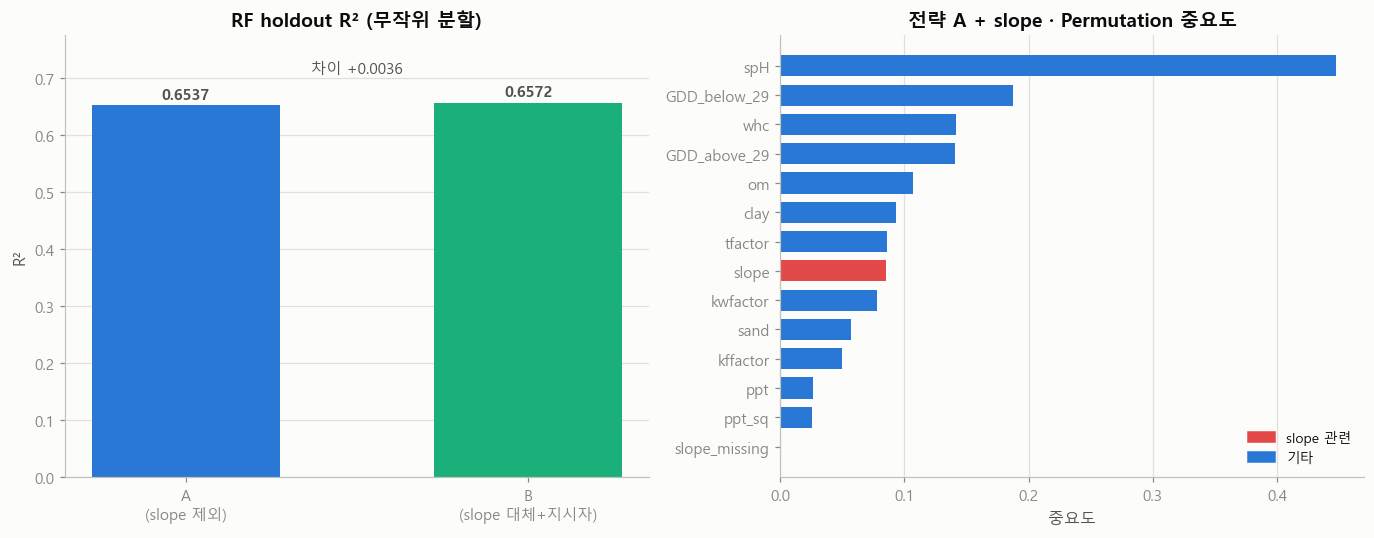

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 5.0))

ax = axes[0]; ax.set_axisbelow(True); ax.grid(axis='x', visible=False)
names = ['A\n(slope 제외)', 'B\n(slope 대체+지시자)']
vals = [scA['rf'], scB['rf']]
ax.bar(names, vals, color=[BLUE, AQUA], width=0.55)
for i, v in enumerate(vals):
    ax.annotate('%.4f' % v, xy=(i, v), xytext=(0, 4), textcoords='offset points',
                ha='center', color=SECOND, fontsize=10, fontweight='semibold')
ax.set_ylim(0, max(vals) * 1.18)
ax.set_title('RF holdout R² (무작위 분할)'); ax.set_ylabel('R²')
ax.annotate('차이 %+.4f' % (scB['rf'] - scA['rf']), xy=(0.5, max(vals) * 1.08),
            ha='center', color=SECOND, fontsize=10)

ax = axes[1]; ax.set_axisbelow(True); ax.grid(axis='y', visible=False)
o = impB.sort_values('perm_imp')
cols = [RED if f in ('slope', 'slope_missing') else BLUE for f in o.feature]
ax.barh(o.feature, o.perm_imp, color=cols, height=0.72)
ax.set_title('전략 A + slope · Permutation 중요도')
ax.set_xlabel('중요도')
h = [plt.Rectangle((0, 0), 1, 1, color=RED), plt.Rectangle((0, 0), 1, 1, color=BLUE)]
ax.legend(h, ['slope 관련', '기타'], frameon=False, fontsize=9, loc='lower right')

fig.tight_layout()
save(fig, 'fig12_slope_versions.png'); plt.show()

**해석 — `slope`는 약하고, `slope_missing`은 무의미하다.**

- RF 홀드아웃 R² 개선은 **+0.0036** (0.6537 → 0.6572) 로 사실상 무시할 수준.
- `slope`의 permutation 중요도 순위는 14개 중 **8위** — 중간. `slope_missing`은 **14위(≈0)** 로,
  결측 여부 자체에는 정보가 없다.
- 즉 **MNAR 결측이지만 결측 패턴이 수확량과 연관되지는 않는다**. 대체값을 넣어도 얻는 게 거의 없다.
- **결론: 기본은 버전 A(slope 제외)로 간다.** 다만 두 컬럼을 parquet에 함께 저장해 두었으니
  04에서 필요하면 즉시 버전 B로 전환할 수 있다.

## 6. 저장

- `features_stratA.parquet` — 도메인 압축 피처 (임계 4버전 모두)
- `features_stratB.parquet` — 온도구간 원자료 (기준 구간 drop)
- `feature_columns.json` — 각 전략의 컬럼 그룹 정의

두 파일 모두 `slope`, `slope_missing`을 **포함**한다. **버전 A = 이 두 컬럼을 빼면 된다.**

In [15]:
KEYS = ['stco', 'year']
TARGETS = ['corn', 'corn_dm']
CARRY = ['A_c', 'silt', 'GDD_cold']    # 모델 피처 아님 (A_c는 06 최적화용, silt/GDD_cold는 참고)
SLOPE_COLS = ['slope', 'slope_missing']

gdd_pairs = []
for t in THRESHOLDS:
    gdd_pairs += ['GDD_below_%d' % t, 'GDD_above_%d' % t]

colsA = KEYS + TARGETS + CARRY + gdd_pairs + ['ppt', 'ppt_sq'] + SOIL_FEAT + SLOPE_COLS
colsB = KEYS + TARGETS + CARRY + GDD_B + ['ppt', 'ppt_sq'] + SOIL_FEAT + SLOPE_COLS

fa, fb = df[colsA].copy(), df[colsB].copy()
fa.to_parquet(PROC / 'features_stratA.parquet', index=False)
fb.to_parquet(PROC / 'features_stratB.parquet', index=False)
print('features_stratA.parquet', fa.shape)
print('features_stratB.parquet', fb.shape)

spec = {
    'panel_rows': int(len(df)),
    'counties': int(df.stco.nunique()),
    'year_range': [int(df.year.min()), int(df.year.max())],
    'keys': KEYS,
    'targets': {'corn': '옥수수 수확량 bu/ac (원본)',
                'corn_dm': 'corn - 연도평균 (기술추세 제거, 중요도/기후분석용 권장 타깃)'},
    'carry_not_features': {'A_c': '카운티 농지규모 (06 최적화용 가중치)',
                           'silt': 'sand+silt+clay=100 이라 모델에서 제외 (복원 가능)',
                           'GDD_cold': '≤0℃ 일수 = 전략A의 reference 구간 (모델 투입 금지)'},
    'imputation': {'gddm4': '184 - 나머지 120개 합 으로 복원 (1행)',
                   'soil_minor': '중앙값 %d셀(8개 컬럼) + silt %d셀은 100-sand-clay 로 복원' % (n_med, n_silt),
                   'slope': '주(state) 중앙값 + slope_missing 지시자 (%d행)' % n_slope},
    'strategy_A': {
        'description': 'Schlenker-Roberts 도메인 압축. reference = ≤0℃ 냉량 구간(GDD_cold).',
        'canonical_threshold': CANON_T,
        'thresholds_available': THRESHOLDS,
        'gdd_canonical': ['GDD_below_%d' % CANON_T, 'GDD_above_%d' % CANON_T],
        'gdd_all': gdd_pairs,
        'ppt': ['ppt', 'ppt_sq'],
        'soil': SOIL_FEAT,
        'slope_optional': SLOPE_COLS,
        'features_versionA': FEAT_A_noslope,
        'features_versionB': FEAT_A_slope,
        'coef_warning': '개별 b_below/b_above 는 ≤0℃ 대비 효과. 해석은 b_above - b_below (대체효과)로.',
    },
    'strategy_B': {
        'description': '노출 있는 온도구간 원자료. Ridge/Lasso 전용 (공선성 0.94).',
        'reference_bin_dropped': REF_BIN,
        'reference_bin_temp_C': int(temp_of(REF_BIN)),
        'gdd_bins': GDD_B,
        'n_gdd_bins': len(GDD_B),
        'ppt': ['ppt', 'ppt_sq'],
        'soil': SOIL_FEAT,
        'slope_optional': SLOPE_COLS,
        'scaling': 'parquet 에는 원 스케일 저장. StandardScaler 는 CV 파이프라인 안에서 학습 fold에만 fit 할 것 (누수 방지).',
    },
    'threshold_sensitivity': {'best_simple': best_s, 'best_full': best_f,
                              'note': '28-31 사이 R² 차이 1%p 미만의 얕은 고원'},
    'eval_warning': '무작위 분할은 카운티 고정효과 누수로 R²를 부풀림 (0.654 vs 0.448). GroupKFold(stco) 또는 연도 분할 사용.',
}
with open(PROC / 'feature_columns.json', 'w', encoding='utf-8') as f:
    json.dump(spec, f, ensure_ascii=False, indent=2)
print('feature_columns.json 저장 완료')

features_stratA.parquet (70721, 27)
features_stratB.parquet (70721, 105)
feature_columns.json 저장 완료


### 컬럼 사전

| 그룹 | 컬럼 | 설명 |
|---|---|---|
| 키 | `stco`, `year` | 카운티 FIPS, 연도 |
| 타깃 | `corn` | 수확량 bu/ac |
| 타깃 | `corn_dm` | `corn` − 해당 연도 전국평균 (기술추세 제거) |
| 전략A | `GDD_below_{28,29,30,31}` | 1℃~T℃ 노출 일수 합 (유익) |
| 전략A | `GDD_above_{28,29,30,31}` | T℃ 초과 노출 일수 합 (유해) |
| 전략B | `gddm36`…`gddp50` (86개) | 1℃ 구간별 노출 일수. **`gddp24` 는 reference로 제외됨** |
| 공통 | `ppt`, `ppt_sq` | 생육기 강수량(mm)과 그 제곱 |
| 공통 | `whc, sand, clay, om, kwfactor, kffactor, spH, tfactor` | soil 8개 (**`silt` 제외**) |
| 선택 | `slope`, `slope_missing` | 버전 B에서만 사용. 빼면 버전 A |
| 참고 | `A_c` | 카운티 농지규모 (06 최적화 가중치) |
| 참고 | `GDD_cold` | ≤0℃ 일수 = 전략A reference. **모델에 넣지 말 것** |
| 참고 | `silt` | 복원용으로만 보관 |

## 7. 요약

In [16]:
print('=' * 66)
print('03 FEATURE ENGINEERING 요약')
print('=' * 66)
print('[결측 처리]')
print('  gddm4 1개    : 184 - 나머지합 = %.3f 로 복원' % recon.iloc[0])
print('  soil %d셀     : 중앙값 %d + silt 제약복원 %d' % (n_minor, n_med, n_silt))
print('  slope %d행 : 주 중앙값 + slope_missing 지시자 (버전 B)' % n_slope)
print()
print('[더미변수 함정 2개 해소]')
print('  gdd 총합 184 -> 전략A: 냉량(<=0C) reference / 전략B: %s drop' % REF_BIN)
print('  sand+silt+clay=100 -> silt 제외')
print()
print('[임계점 민감도]')
print('  simple 최대 T=%d (R2 %.4f) / full 최대 T=%d (R2 %.4f)'
      % (best_s, sens.R2_simple.max(), best_f, sens.R2_full.max()))
print('  28~31 R2 차이 %.4f -> 얕은 고원, 날카로운 임계 아님'
      % (sens[sens.thr.isin(THRESHOLDS)].R2_full.max() - sens[sens.thr.isin(THRESHOLDS)].R2_full.min()))
print('  b_above 부호 전환 지점 T=%d' % zc)
print()
print('[피처 중요도 (perm, 전략A)]')
for i, (f, v) in enumerate(zip(impA.feature[:5], impA.perm_imp[:5]), 1):
    print('  %d. %-14s %.4f' % (i, f, v))
print('  GDD_above_%d 순위: %d / %d'
      % (CANON_T, list(impA.feature).index('GDD_above_%d' % CANON_T) + 1, len(FEAT_A_noslope)))
print()
print('[slope]')
print('  RF R2  A %.4f -> B %.4f (%+.4f), slope 순위 %d/%d, slope_missing ~0'
      % (scA['rf'], scB['rf'], scB['rf'] - scA['rf'], rank_slope, len(FEAT_A_slope)))
print('  => 기본은 버전 A (slope 제외)')
print()
print('[04 에서 비교할 것]')
print('  전략 A(압축 12피처) vs 전략 B(온도구간 %d + 나머지)' % len(GDD_B))
print('  slope 버전 A vs B')
print('  임계 T = 28/29/30/31')
print('  평가 분할: GroupKFold(stco) 또는 연도 홀드아웃 (무작위 분할 금지)')
print()
print('저장: features_stratA%s  features_stratB%s  feature_columns.json' % (fa.shape, fb.shape))

03 FEATURE ENGINEERING 요약
[결측 처리]
  gddm4 1개    : 184 - 나머지합 = 2.310 로 복원
  soil 36셀     : 중앙값 32 + silt 제약복원 4
  slope 2061행 : 주 중앙값 + slope_missing 지시자 (버전 B)

[더미변수 함정 2개 해소]
  gdd 총합 184 -> 전략A: 냉량(<=0C) reference / 전략B: gddp24 drop
  sand+silt+clay=100 -> silt 제외

[임계점 민감도]
  simple 최대 T=28 (R2 0.0641) / full 최대 T=31 (R2 0.2465)
  28~31 R2 차이 0.0089 -> 얕은 고원, 날카로운 임계 아님
  b_above 부호 전환 지점 T=27

[피처 중요도 (perm, 전략A)]
  1. spH            0.4562
  2. GDD_below_29   0.1891
  3. GDD_above_29   0.1477
  4. whc            0.1432
  5. om             0.1328
  GDD_above_29 순위: 3 / 12

[slope]
  RF R2  A 0.6537 -> B 0.6572 (+0.0036), slope 순위 8/14, slope_missing ~0
  => 기본은 버전 A (slope 제외)

[04 에서 비교할 것]
  전략 A(압축 12피처) vs 전략 B(온도구간 86 + 나머지)
  slope 버전 A vs B
  임계 T = 28/29/30/31
  평가 분할: GroupKFold(stco) 또는 연도 홀드아웃 (무작위 분할 금지)

저장: features_stratA(70721, 27)  features_stratB(70721, 105)  feature_columns.json
